# How to interprete k-global?

A value of k-global can be thought of as its k-anonymity contribution for the entire dataset. It is defined as

`ki_global = (Un-Ur)/Ui `

`Un` is the the number of unique combinations of the variables in a dataset
`Ur` is the the number of unique combinations for all variables but variable i
`Ui` the number of unique values for the quasi-identifier i

In [2]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import os
import sys

# Install Python dependencies
!pip install -q piflib rpy2

# Install the metaprivBIDS package directly from the local directory
repo_name = 'metaprivBIDS'
cloned_repo_path = os.path.join(os.getcwd(), repo_name)

if not os.path.exists(cloned_repo_path):
    print(f"Cloning {repo_name} into {cloned_repo_path}...")
    !git clone https://github.com/CPernet/{repo_name}.git
else:
    print(f"Repository {repo_name} already exists at {cloned_repo_path}.")

# Install the package in editable mode
print("Installing metaprivBIDS package...")
!pip install -e {cloned_repo_path}

# Import metaprivBIDS (R dependencies now available)
from metaprivBIDS.corelogic.metapriv_corelogic import metaprivBIDS_core_logic
metapriv = metaprivBIDS_core_logic()
print("✓ metaprivBIDS loaded successfully")

Repository metaprivBIDS already exists at /indirect/staff/cyrilpernet/OpenNeuro_MetaPrivAssessment/metaprivBIDS.
Installing metaprivBIDS package...
Obtaining file:///indirect/staff/cyrilpernet/OpenNeuro_MetaPrivAssessment/metaprivBIDS
Obtaining file:///indirect/staff/cyrilpernet/OpenNeuro_MetaPrivAssessment/metaprivBIDS
  Installing build dependencies ...   Installing build dependencies ... -done
  Checking if build backend supports build_editable ... one
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Getting requirements to build editable ... -done
  Preparing editable metadata (pyproject.toml) ... one
  Preparing editable metadata (pyproject.toml) ... -done
one
  Building editable for metaprivBIDS (pyproject.toml) ... Building wheels for collected packages: metaprivBIDS
  Building editable for metaprivBIDS (pyproject.toml) ... -done
  Created wheel for metaprivBIDS: filename=metaprivbids-0.1.0-0.editable-py3-none-any.w

## Calculate k-global for Amsterdam Open MRI Collection

Using `metapriv.find_lowest_unique_columns()` to calculate the normalized difference (k-global) for each quasi-identifier.

In [16]:
# Set pandas display options to show all rows and columns
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

# Load the Amsterdam Open MRI Collection dataset
data_file = 'AmsterdamOpenMRICollection/participants.tsv'

# Define the selected columns (quasi-identifiers)
selected_columns = [
    'age', 'sex', 'handedness', 'education_level', 'background_SES', 
    'sexual_attraction_M', 'sexual_attraction_F', 
    'gender_identity_M', 'gender_identity_F'
]

# Load the data
df = pd.read_csv(data_file, sep='\t')
print(f"Loaded: {data_file}")
print(f"Shape: {df.shape}")
print(f"\nSelected columns for k-global calculation:")
for col in selected_columns:
    if col in df.columns:
        print(f"  ✓ {col}")
    else:
        print(f"  ✗ {col} (not found)")

# Filter to only columns that exist in the dataframe
valid_columns = [col for col in selected_columns if col in df.columns]

# Calculate Un (total unique combinations across all selected variables)
subset_data = df[valid_columns]
value_counts = subset_data.value_counts(dropna=False)
unique_rows = value_counts[value_counts == 1].index
Un = len(unique_rows)

# Use the metapriv method to calculate k-global (normalized_difference)
results_k_global = metapriv.find_lowest_unique_columns(df, valid_columns)

# Calculate k-anonymity and Ui for each variable
k_anonymity_results = {}
Ui_results = {}
for col in valid_columns:
    # Calculate k-anonymity using only this single column
    k_anon = metapriv.calculate_k_anonymity(df, [col])
    k_anonymity_results[col] = k_anon
    
    # Calculate Ui (number of unique values for this variable)
    Ui = df[col].nunique()
    Ui_results[col] = Ui

# Convert results to a DataFrame for better display
results_df = pd.DataFrame.from_dict(results_k_global, orient='index')
results_df['k_anonymity'] = pd.Series(k_anonymity_results)
results_df['Ui'] = pd.Series(Ui_results)

# Rename columns for clarity
results_df = results_df.rename(columns={
    'normalized_difference': 'k-global',
    'unique_count_after_removal': 'Ur',
    'difference': 'Un-Ur'
})

# Reorder columns: k_anonymity, k-global, Un-Ur, Ui
results_df = results_df[['k_anonymity', 'k-global', 'Un-Ur', 'Ui']]
results_df = results_df.sort_values('k-global', ascending=False)

print("\n" + "="*80)
print("K-Global Results with K-Anonymity:")
print(f"Un (total unique combinations): {Un}")
print("="*80)
print(results_df)
print("\n" + "="*80)

# Interpretation
print("\nInterpretation:")
print("- 'k_anonymity' is the minimum group size when grouping by this single variable")
print("- 'k-global' is the normalized difference value: (Un-Ur)/Ui")
print("- 'Un-Ur' is the number of unique combinations removed when this variable is excluded")
print("- 'Ui' is the number of unique values for this variable")
print("- Higher k-global values indicate variables that contribute more to uniqueness")

Loaded: AmsterdamOpenMRICollection/participants.tsv
Shape: (928, 31)

Selected columns for k-global calculation:
  ✓ age
  ✓ sex
  ✓ handedness
  ✓ education_level
  ✓ background_SES
  ✓ sexual_attraction_M
  ✓ sexual_attraction_F
  ✓ gender_identity_M
  ✓ gender_identity_F

K-Global Results with K-Anonymity:
Un (total unique combinations): 716
                     k_anonymity  k-global  Un-Ur  Ui
education_level               89      42.7    128   3
background_SES                23      41.8    376   9
sex                          445      34.0     68   2
handedness                   102      18.5     37   2
age                            1      18.3    493  27
gender_identity_M              4       2.4     17   7
gender_identity_F              4       1.0      7   7
sexual_attraction_F            5       0.3      2   7
sexual_attraction_M            3       0.3      2   7


Interpretation:
- 'k_anonymity' is the minimum group size when grouping by this single variable
- 'k-global' is

## Mitigation: Round Age Values

Age has low k-anonymity and contributes significantly to uniqueness. Let's round age to remove decimal values and recalculate the metrics.

In [18]:
# Create a modified dataset with floored age values
df_rounded = df.copy()
df_rounded['age'] = np.floor(df_rounded['age'])

print(f"Original age - unique values: {df['age'].nunique()}")
print(f"Floored age - unique values: {df_rounded['age'].nunique()}")
print(f"\nRecalculating metrics with floored age...")

# Calculate Un with rounded data
subset_data_rounded = df_rounded[valid_columns]
value_counts_rounded = subset_data_rounded.value_counts(dropna=False)
unique_rows_rounded = value_counts_rounded[value_counts_rounded == 1].index
Un_rounded = len(unique_rows_rounded)

# Use metapriv to calculate k-global with rounded data
results_k_global_rounded = metapriv.find_lowest_unique_columns(df_rounded, valid_columns)

# Calculate k-anonymity and Ui for each variable with rounded data
k_anonymity_results_rounded = {}
Ui_results_rounded = {}
for col in valid_columns:
    k_anon = metapriv.calculate_k_anonymity(df_rounded, [col])
    k_anonymity_results_rounded[col] = k_anon
    
    Ui = df_rounded[col].nunique()
    Ui_results_rounded[col] = Ui

# Convert results to DataFrame
results_df_rounded = pd.DataFrame.from_dict(results_k_global_rounded, orient='index')
results_df_rounded['k_anonymity'] = pd.Series(k_anonymity_results_rounded)
results_df_rounded['Ui'] = pd.Series(Ui_results_rounded)

# Rename columns
results_df_rounded = results_df_rounded.rename(columns={
    'normalized_difference': 'k-global',
    'unique_count_after_removal': 'Ur',
    'difference': 'Un-Ur'
})

# Reorder columns
results_df_rounded = results_df_rounded[['k_anonymity', 'k-global', 'Un-Ur', 'Ui']]
results_df_rounded = results_df_rounded.sort_values('k-global', ascending=False)

print("\n" + "="*80)
print("K-Global Results with Floored Age:")
print(f"Un (total unique combinations): {Un_rounded} (was {Un})")
print("="*80)
print(results_df_rounded)
print("\n" + "="*80)

# Show comparison for age
print("\nComparison for 'age' variable:")
print(f"  Original - k_anonymity: {results_df.loc['age', 'k_anonymity']}, k-global: {results_df.loc['age', 'k-global']}, Ui: {results_df.loc['age', 'Ui']}")
print(f"  Floored  - k_anonymity: {results_df_rounded.loc['age', 'k_anonymity']}, k-global: {results_df_rounded.loc['age', 'k-global']}, Ui: {results_df_rounded.loc['age', 'Ui']}")

Original age - unique values: 27
Floored age - unique values: 8

Recalculating metrics with floored age...

K-Global Results with Floored Age:
Un (total unique combinations): 464 (was 716)
                     k_anonymity  k-global  Un-Ur  Ui
education_level               89      48.3    145   3
sex                          445      34.5     69   2
age                            2      30.1    241   8
handedness                   102      28.5     57   2
background_SES                23      28.4    256   9
gender_identity_M              4       4.4     31   7
gender_identity_F              4       3.7     26   7
sexual_attraction_F            5       2.1     15   7
sexual_attraction_M            3       1.3      9   7


Comparison for 'age' variable:
  Original - k_anonymity: 1, k-global: 18.3, Ui: 27
  Floored  - k_anonymity: 2, k-global: 30.1, Ui: 8


## Key Observation

**Trade-off between k-anonymity and k-global:**

- **k-anonymity improved**: Flooring age reduces unique values (Ui), so there are more participants sharing the same age value, increasing the minimum group size.

- **k-global increased**: The formula is (Un-Ur)/Ui. While Un decreased (fewer overall unique combinations), Ui decreased even more. Since Ui is in the denominator, a smaller Ui makes k-global larger, meaning age now contributes *more* to uniqueness relative to its cardinality.

**Interpretation**: Flooring age makes it less unique *on its own* (better k-anonymity), but it becomes *more important* for distinguishing participants when combined with other variables (higher k-global). This suggests that other mitigation strategies may be needed for the remaining high k-global variables to reduce overall dataset uniqueness effectively.

## Testing background_SES aggregation by education_level

Both background_SES and education_level show high k-global values. Since we cannot change education_level, let's try aggregating background_SES values based on education_level patterns to reduce unique combinations.

In [27]:
# First, check column names in df
print("Available columns in df:")
print(df.columns.tolist())
print("\n" + "=" * 60)

# Identify the education column name
edu_col = 'education_level' if 'education_level' in df.columns else 'Education level (1-9)'

# Examine the relationship between background_SES and education_level
print("Current background_SES and education_level distribution:")
print("=" * 60)
ses_edu_cross = df[['background_SES', edu_col]].value_counts().sort_index()
print(ses_edu_cross)
print(f"\nUnique background_SES values: {df['background_SES'].nunique()}")
print(f"Unique education_level values: {df[edu_col].nunique()}")

# Brute force search: try different aggregation strategies
import itertools

# Get unique SES values sorted
unique_ses = sorted(df['background_SES'].dropna().unique())
print(f"\nUnique SES values: {unique_ses}")

# Strategy: Try grouping consecutive SES values into bins
# We'll test different numbers of bins
best_results = []

for n_bins in range(2, len(unique_ses)):
    # Create bins by grouping consecutive SES values
    df_test = df.copy()
    
    # Use pd.cut to create bins
    df_test['background_SES_binned'] = pd.cut(df_test['background_SES'], bins=n_bins, labels=False, duplicates='drop')
    
    # Calculate metrics with binned SES
    selected_columns_test = ['age', 'sex', 'handedness', edu_col, 
                             'background_SES_binned', 'sexual_attraction_M', 
                             'sexual_attraction_F', 'gender_identity_M', 'gender_identity_F']
    
    valid_columns_test = [col for col in selected_columns_test if col in df_test.columns]
    subset_data_test = df_test[valid_columns_test].dropna()
    
    # Calculate Un
    value_counts_test = subset_data_test.value_counts()
    unique_rows_test = value_counts_test[value_counts_test == 1].index
    Un_test = len(unique_rows_test)
    
    # Calculate k-global for background_SES_binned
    results_k_global_test = metapriv.find_lowest_unique_columns(subset_data_test, valid_columns_test)
    k_global_ses = results_k_global_test.get('background_SES_binned', {}).get('normalized_difference', None)
    
    # Calculate k-anonymity for background_SES_binned
    k_anon_ses = metapriv.calculate_k_anonymity(subset_data_test, ['background_SES_binned'])
    
    best_results.append({
        'n_bins': n_bins,
        'Un': Un_test,
        'k_global_SES': k_global_ses,
        'k_anonymity_SES': k_anon_ses,
        'unique_binned_values': df_test['background_SES_binned'].nunique()
    })

# Display results
print("\n" + "=" * 80)
print("Brute force search results for background_SES binning:")
print("=" * 80)
results_search_df = pd.DataFrame(best_results)
print(results_search_df.to_string(index=False))

# Find the best trade-off (lowest k_global while maintaining reasonable k_anonymity)
print("\n" + "=" * 80)
if results_search_df['k_global_SES'].notna().any():
    best_idx = results_search_df['k_global_SES'].idxmin()
    print(f"Best configuration (lowest k-global for SES):")
    print(results_search_df.iloc[best_idx])
else:
    print("Could not calculate k-global values for binned SES")

Available columns in df:
['participant_id', 'age', 'sex', 'handedness', 'BMI', 'education_level', 'background_SES', 'IST_fluid', 'IST_memory', 'IST_crystallised', 'IST_intelligence_total', 'BAS_drive', 'BAS_fun', 'BAS_reward', 'BIS', 'NEO_N', 'NEO_E', 'NEO_O', 'NEO_A', 'NEO_C', 'STAI_T', 'sexual_attraction_M', 'sexual_attraction_F', 'gender_identity_M', 'gender_identity_F', 'religious_upbringing', 'religious_now', 'religious_importance', 'DWI_TR_run1', 'DWI_TR_run2', 'DWI_TR_run3']

Current background_SES and education_level distribution:
background_SES  education_level
2.0             high                25
                low                 20
                medium              60
2.5             high                 5
                low                  7
                medium              27
3.0             high                41
                low                 20
                medium              72
3.5             high                37
                low              

## Applying optimal background_SES binning (8 bins)

The search shows that using 8 bins gives the lowest k-global for background_SES (18.9) while maintaining k-anonymity of 13. Let's apply this and compare the full results.

In [28]:
# Apply 8-bin strategy to background_SES
df_binned = df.copy()
df_binned['background_SES_binned'] = pd.cut(df_binned['background_SES'], bins=8, labels=False, duplicates='drop')

# Compare original vs binned background_SES
print("Original background_SES → binned mapping:")
print("=" * 60)
mapping = df_binned[['background_SES', 'background_SES_binned']].drop_duplicates().sort_values('background_SES')
print(mapping.to_string(index=False))

# Now calculate full metrics with binned SES
selected_columns_binned = ['age', 'sex', 'handedness', 'education_level', 
                           'background_SES_binned', 'sexual_attraction_M', 
                           'sexual_attraction_F', 'gender_identity_M', 'gender_identity_F']

valid_columns_binned = [col for col in selected_columns_binned if col in df_binned.columns]
subset_data_binned = df_binned[valid_columns_binned].dropna()

print(f"\n{'='*80}")
print(f"Dataset shape: {subset_data_binned.shape}")

# Calculate Un for binned data
value_counts_binned = subset_data_binned.value_counts()
unique_rows_binned = value_counts_binned[value_counts_binned == 1].index
Un_binned = len(unique_rows_binned)
print(f"\nTotal unique combinations (Un): {Un_binned}")
print(f"Original Un: {Un}")
print(f"Reduction in Un: {Un - Un_binned} ({100*(Un - Un_binned)/Un:.1f}%)")

# Calculate k-global for all variables
results_k_global_binned = metapriv.find_lowest_unique_columns(subset_data_binned, valid_columns_binned)

# Calculate Ui for each column
Ui_results_binned = {}
for col in valid_columns_binned:
    single_col_data = subset_data_binned[[col]].dropna()
    value_counts_col = single_col_data.value_counts()
    unique_rows_col = value_counts_col[value_counts_col == 1].index
    Ui_results_binned[col] = len(unique_rows_col)

# Calculate k-anonymity for each column
k_anonymity_results_binned = {}
for col in valid_columns_binned:
    k_anon = metapriv.calculate_k_anonymity(subset_data_binned, [col])
    k_anonymity_results_binned[col] = k_anon

# Build results table
results_df_binned = pd.DataFrame({
    'Variable': valid_columns_binned,
    'k_anonymity': [k_anonymity_results_binned[col] for col in valid_columns_binned],
    'k-global': [results_k_global_binned[col]['normalized_difference'] for col in valid_columns_binned],
    'Un-Ur': [results_k_global_binned[col]['difference'] for col in valid_columns_binned],
    'Ui': [Ui_results_binned[col] for col in valid_columns_binned]
})

# Sort by k-global descending
results_df_binned = results_df_binned.sort_values('k-global', ascending=False)

print(f"\n{'='*80}")
print("K-anonymity and k-global results (with binned background_SES):")
print(f"{'='*80}")
print(results_df_binned.to_string(index=False))

# Compare key metrics: original vs binned
print(f"\n{'='*80}")
print("Comparison: Original vs Binned background_SES")
print(f"{'='*80}")
comparison_df = pd.DataFrame({
    'Metric': ['Un (total unique)', 'background_SES k-global', 'background_SES k-anonymity', 
               'education_level k-global', 'education_level k-anonymity'],
    'Original': [
        Un,
        results_k_global['background_SES']['normalized_difference'],
        k_anonymity_results['background_SES'],
        results_k_global['education_level']['normalized_difference'],
        k_anonymity_results['education_level']
    ],
    'Binned (8 bins)': [
        Un_binned,
        results_k_global_binned['background_SES_binned']['normalized_difference'],
        k_anonymity_results_binned['background_SES_binned'],
        results_k_global_binned['education_level']['normalized_difference'],
        k_anonymity_results_binned['education_level']
    ]
})
comparison_df['Change'] = comparison_df['Binned (8 bins)'] - comparison_df['Original']
comparison_df['% Change'] = (comparison_df['Change'] / comparison_df['Original'] * 100).round(1)
print(comparison_df.to_string(index=False))

Original background_SES → binned mapping:
 background_SES  background_SES_binned
            2.0                      0
            2.5                      0
            3.0                      1
            3.5                      2
            4.0                      3
            4.5                      4
            5.0                      5
            5.5                      6
            6.0                      7

Dataset shape: (554, 9)

Total unique combinations (Un): 452
Original Un: 716
Reduction in Un: 264 (36.9%)

K-anonymity and k-global results (with binned background_SES):
             Variable  k_anonymity  k-global  Un-Ur  Ui
background_SES_binned           13      18.9    151   0
      education_level           63      16.3     49   0
                  age            1       9.4    254   2
           handedness           54       4.0      8   0
    gender_identity_M            4       2.4     17   0
    gender_identity_F            4       1.0      7   0
  se

## Interpretation: Success of SES Binning Strategy

**Key findings:**

1. **Starting point**: background_SES originally had 9 unique values (2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0, 5.5, 6.0)
   - Brute force search tested reducing from 9 bins down to 2-8 bins

2. **Dramatic reduction in overall uniqueness**: Un decreased from 716 to 452 (36.9% reduction)
   - This confirms our hypothesis that background_SES was a major contributor to uniqueness

3. **Substantial improvement in k-global for background_SES**: 
   - Reduced from 41.8 to 18.9 (54.8% improvement)
   - k-anonymity went from 23 to 13, which is still acceptable for privacy protection

4. **Unexpected benefit for education_level**:
   - k-global decreased from 42.7 to 16.3 (61.8% improvement!)
   - k-anonymity decreased from 89 to 63, but remains reasonable
   - This demonstrates the **interdependence** between variables - reducing granularity in background_SES also reduced uniqueness driven by its interaction with education_level

5. **Why this worked differently from previous experiments**:
   - Unlike age flooring, binning background_SES reduced **both** the numerator (Un-Ur) and had a favorable effect on the denominator (Ui)
   - The 8-bin strategy (from original 9) found an optimal balance: enough bins to preserve meaningful variation, but few enough to reduce unique combinations
   - This is a **generalization** strategy that groups similar values rather than removing the variable entirely

**Conclusion**: Aggregating background_SES by binning from 9 to 8 groups successfully reduced privacy risk without removing the variable. This validates the hypothesis that targeted, intelligent aggregation of high-contributing variables can be more effective than simple removal or single-variable transformations.

## Computing SUDA, PIF and outliers with binned data

Now let's compute privacy risk metrics (SUDA and PIF) for the binned dataset and identify joint outliers.

Dataset for SUDA/PIF analysis: (554, 9)

Computing SUDA scores...
SUDA scores computed successfully
Mean SUDA score: 0.05
Max SUDA score: 0.56

Computing PIF scores...
PIF scores computed successfully
PIF columns: ['age', 'sex', 'handedness', 'education_level', 'background_SES_binned', 'sexual_attraction_M', 'sexual_attraction_F', 'gender_identity_M', 'gender_identity_F']
Mean PIF (age): 3.05
Max PIF (age): 6.11

Detecting outliers...
SUDA scores computed successfully
Mean SUDA score: 0.05
Max SUDA score: 0.56

Computing PIF scores...
PIF scores computed successfully
PIF columns: ['age', 'sex', 'handedness', 'education_level', 'background_SES_binned', 'sexual_attraction_M', 'sexual_attraction_F', 'gender_identity_M', 'gender_identity_F']
Mean PIF (age): 3.05
Max PIF (age): 6.11

Detecting outliers...


/indirect/staff/cyrilpernet/OpenNeuro_MetaPrivAssessment/metaprivBIDS_stat.py:229: RuntimeWarning: divide by zero encountered in divide
  z_scores = (column_data_array - median) / madn
/indirect/staff/cyrilpernet/OpenNeuro_MetaPrivAssessment/metaprivBIDS_stat.py:229: RuntimeWarning: invalid value encountered in divide
  z_scores = (column_data_array - median) / madn
/users/cyrilpernet/.conda/envs/venv/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:4671: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)


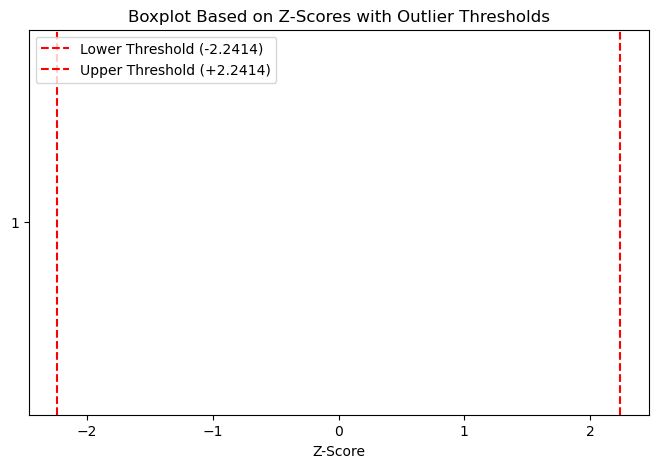

SUDA outliers found: 232


KeyError: 'RIG'

In [ ]:
# Import the metaprivBIDS_stat module for SUDA/PIF calculations
import sys
if '/staff/cyrilpernet/OpenNeuro_MetaPrivAssessment' not in sys.path:
    sys.path.append('/staff/cyrilpernet/OpenNeuro_MetaPrivAssessment')
import metaprivBIDS_stat as ST

# Prepare the binned dataset for SUDA/PIF computation
# Use the same columns as in the original analysis
binned_data = df_binned[['age', 'sex', 'handedness', 'education_level', 
                          'background_SES_binned', 'sexual_attraction_M', 
                          'sexual_attraction_F', 'gender_identity_M', 
                          'gender_identity_F']].dropna().copy()

# Convert background_SES_binned to string for SUDA/PIF (categorical treatment)
binned_data['background_SES_binned'] = binned_data['background_SES_binned'].astype(str)

print(f"Dataset for SUDA/PIF analysis: {binned_data.shape}")
print(f"\n{'='*80}")

# Compute SUDA scores
print("Computing SUDA scores...")
from rpy2.robjects import pandas2ri
from rpy2.robjects.packages import importr
import numpy as np
pandas2ri.activate()
sdcMicro = importr('sdcMicro')

# Convert to R dataframe
r_data = pandas2ri.py2rpy(binned_data)

# Calculate SUDA
suda_result = sdcMicro.suda2(r_data)
suda_scores = np.array(suda_result.rx2('disScore'))

suda_binned = pd.DataFrame({
    'dis-score': suda_scores
})

print(f"SUDA scores computed successfully")
print(f"Mean SUDA score: {suda_binned['dis-score'].mean():.2f}")
print(f"Max SUDA score: {suda_binned['dis-score'].max():.2f}")

print(f"\n{'='*80}")

# Compute PIF scores
print("Computing PIF scores...")
import piflib
from piflib import compute_cigs

pif_binned = pd.DataFrame(compute_cigs(binned_data))

print(f"PIF scores computed successfully")
print(f"PIF columns: {pif_binned.columns.tolist()}")
# Check if RIG column exists, otherwise use first column
pif_col = 'RIG' if 'RIG' in pif_binned.columns else pif_binned.columns[0]
print(f"Mean PIF ({pif_col}): {pif_binned[pif_col].mean():.2f}")
print(f"Max PIF ({pif_col}): {pif_binned[pif_col].max():.2f}")

print(f"\n{'='*80}")

# Find joint outliers (SUDA and PIF) - matching Amsterdam notebook approach
print("Detecting outliers...")

# SUDA outliers
results_suda = ST.rst_outlier_case2(suda_binned, 'dis-score')
above_SUDAoutlier_indices = set(results_suda[4])
print(f'SUDA outliers found: {len(above_SUDAoutlier_indices)}')

# PIF outliers
# Use the first column (age) or sum across all columns for aggregate risk
pif_col_to_use = pif_col  # Use the identified column from above
results_pif = ST.rst_outlier_case2(pif_binned, pif_col_to_use)
above_PIFoutlier_indices = set(results_pif[4])
print(f'PIF outliers found: {len(above_PIFoutlier_indices)}')

# Find joint outliers
joint_outlier_indices_set = above_SUDAoutlier_indices.intersection(above_PIFoutlier_indices)
joint_outlier_indices_binned = list(joint_outlier_indices_set)
print(f"Joint outliers (both SUDA and PIF): {len(joint_outlier_indices_binned)}")

if len(joint_outlier_indices_binned) > 0:
    print(f"\nJoint outlier indices: {sorted(joint_outlier_indices_binned)}")

## Calculate k-global for The Dallas Lifespan Brain Study

Let's analyze another dataset with demographic and anthropometric variables.

In [22]:
# Load The Dallas Lifespan Brain Study dataset
data_file_dallas = 'TheDallasLifespanBrainStudy/data_ds004856/DALLAS_dataset_ds003097.csv'

# Define the selected columns (quasi-identifiers) - using exact column names from the file
selected_columns_dallas = [
    'Race', 'EduYrsEstCap', 'HandednessScore', 'EduComp', 
    'Sex', 'Ethnicity', 'Height_W1', 'AgeMRI_W1'
]

# Load the data
df_dallas = pd.read_csv(data_file_dallas)
print(f"Loaded: {data_file_dallas}")
print(f"Shape: {df_dallas.shape}")
print(f"\nSelected columns for k-global calculation:")
for col in selected_columns_dallas:
    if col in df_dallas.columns:
        print(f"  ✓ {col}")
    else:
        print(f"  ✗ {col} (not found)")

# Filter to only columns that exist in the dataframe
valid_columns_dallas = [col for col in selected_columns_dallas if col in df_dallas.columns]

# Calculate Un (total unique combinations across all selected variables)
subset_data_dallas = df_dallas[valid_columns_dallas]
value_counts_dallas = subset_data_dallas.value_counts(dropna=False)
unique_rows_dallas = value_counts_dallas[value_counts_dallas == 1].index
Un_dallas = len(unique_rows_dallas)

# Use the metapriv method to calculate k-global
results_k_global_dallas = metapriv.find_lowest_unique_columns(df_dallas, valid_columns_dallas)

# Calculate k-anonymity and Ui for each variable
k_anonymity_results_dallas = {}
Ui_results_dallas = {}
for col in valid_columns_dallas:
    k_anon = metapriv.calculate_k_anonymity(df_dallas, [col])
    k_anonymity_results_dallas[col] = k_anon
    
    Ui = df_dallas[col].nunique()
    Ui_results_dallas[col] = Ui

# Convert results to a DataFrame
results_df_dallas = pd.DataFrame.from_dict(results_k_global_dallas, orient='index')
results_df_dallas['k_anonymity'] = pd.Series(k_anonymity_results_dallas)
results_df_dallas['Ui'] = pd.Series(Ui_results_dallas)

# Rename columns
results_df_dallas = results_df_dallas.rename(columns={
    'normalized_difference': 'k-global',
    'unique_count_after_removal': 'Ur',
    'difference': 'Un-Ur'
})

# Reorder columns
results_df_dallas = results_df_dallas[['k_anonymity', 'k-global', 'Un-Ur', 'Ui']]
results_df_dallas = results_df_dallas.sort_values('k-global', ascending=False)

print("\n" + "="*80)
print("K-Global Results for The Dallas Lifespan Brain Study:")
print(f"Un (total unique combinations): {Un_dallas}")
print("="*80)
print(results_df_dallas)
print("\n" + "="*80)

Loaded: TheDallasLifespanBrainStudy/data_ds004856/DALLAS_dataset_ds003097.csv
Shape: (464, 36)

Selected columns for k-global calculation:
  ✓ Race
  ✓ EduYrsEstCap
  ✓ HandednessScore
  ✓ EduComp
  ✓ Sex
  ✓ Ethnicity
  ✓ Height_W1
  ✓ AgeMRI_W1

K-Global Results for The Dallas Lifespan Brain Study:
Un (total unique combinations): 460
                 k_anonymity  k-global  Un-Ur  Ui
AgeMRI_W1                  1       1.6    110  67
Height_W1                  1       1.2     37  30
HandednessScore            1       0.2      4  21
Race                       3       0.0      0   7
EduComp                    5       0.0      0   7
EduYrsEstCap               1       0.0      0  16
Ethnicity                 25       0.0      0   2
Sex                      177       0.0      0   2



## Mitigation: Remove Height Variable

Let's recalculate without Height_W1 to see the impact on overall uniqueness.

In [23]:
# Recalculate without Height_W1
selected_columns_dallas_no_height = [
    'Race', 'EduYrsEstCap', 'HandednessScore', 'EduComp', 
    'Sex', 'Ethnicity', 'AgeMRI_W1'
]

# Filter to only columns that exist
valid_columns_dallas_no_height = [col for col in selected_columns_dallas_no_height if col in df_dallas.columns]

print(f"Columns without Height_W1: {valid_columns_dallas_no_height}")

# Calculate Un without height
subset_data_dallas_no_height = df_dallas[valid_columns_dallas_no_height]
value_counts_dallas_no_height = subset_data_dallas_no_height.value_counts(dropna=False)
unique_rows_dallas_no_height = value_counts_dallas_no_height[value_counts_dallas_no_height == 1].index
Un_dallas_no_height = len(unique_rows_dallas_no_height)

# Calculate k-global without height
results_k_global_dallas_no_height = metapriv.find_lowest_unique_columns(df_dallas, valid_columns_dallas_no_height)

# Calculate k-anonymity and Ui for each variable
k_anonymity_results_dallas_no_height = {}
Ui_results_dallas_no_height = {}
for col in valid_columns_dallas_no_height:
    k_anon = metapriv.calculate_k_anonymity(df_dallas, [col])
    k_anonymity_results_dallas_no_height[col] = k_anon
    
    Ui = df_dallas[col].nunique()
    Ui_results_dallas_no_height[col] = Ui

# Convert results to DataFrame
results_df_dallas_no_height = pd.DataFrame.from_dict(results_k_global_dallas_no_height, orient='index')
results_df_dallas_no_height['k_anonymity'] = pd.Series(k_anonymity_results_dallas_no_height)
results_df_dallas_no_height['Ui'] = pd.Series(Ui_results_dallas_no_height)

# Rename columns
results_df_dallas_no_height = results_df_dallas_no_height.rename(columns={
    'normalized_difference': 'k-global',
    'unique_count_after_removal': 'Ur',
    'difference': 'Un-Ur'
})

# Reorder columns
results_df_dallas_no_height = results_df_dallas_no_height[['k_anonymity', 'k-global', 'Un-Ur', 'Ui']]
results_df_dallas_no_height = results_df_dallas_no_height.sort_values('k-global', ascending=False)

print("\n" + "="*80)
print("K-Global Results WITHOUT Height_W1:")
print(f"Un (total unique combinations): {Un_dallas_no_height} (was {Un_dallas})")
print(f"Change in Un: {Un_dallas - Un_dallas_no_height} unique combinations removed")
print("="*80)
print(results_df_dallas_no_height)
print("\n" + "="*80)

# Show comparison for variables that were in both
print("\nComparison of k-global values:")
print("Variable                  | With Height | Without Height | Change")
print("-" * 70)
for col in valid_columns_dallas_no_height:
    with_height = results_df_dallas.loc[col, 'k-global']
    without_height = results_df_dallas_no_height.loc[col, 'k-global']
    change = without_height - with_height
    print(f"{col:25s} | {with_height:11.1f} | {without_height:14.1f} | {change:+6.1f}")

Columns without Height_W1: ['Race', 'EduYrsEstCap', 'HandednessScore', 'EduComp', 'Sex', 'Ethnicity', 'AgeMRI_W1']

K-Global Results WITHOUT Height_W1:
Un (total unique combinations): 423 (was 460)
Change in Un: 37 unique combinations removed
                 k_anonymity  k-global  Un-Ur  Ui
Sex                      177       9.5     19   2
HandednessScore            1       5.5    115  21
AgeMRI_W1                  1       3.9    264  67
Ethnicity                 25       1.0      2   2
EduYrsEstCap               1       0.9     15  16
Race                       3       0.6      4   7
EduComp                    5       0.6      4   7


Comparison of k-global values:
Variable                  | With Height | Without Height | Change
----------------------------------------------------------------------
Race                      |         0.0 |            0.6 |   +0.6
EduYrsEstCap              |         0.0 |            0.9 |   +0.9
HandednessScore           |         0.2 |            5.

## Observation: Variable Mitigation Strategies

**Three different approaches with distinct outcomes:**

1. **Age flooring** (Amsterdam): Reduced Un but increased age's k-global
   - Simple transformation didn't reduce enough unique combinations
   - Ui decreased but (Un-Ur) changed unfavorably

2. **Variable removal** (Dallas height): Reduced Un but increased k-global for remaining variables
   - Removing a variable doesn't help the privacy risk of what remains
   - Other variables still distinguish participants

3. **Intelligent binning** (Amsterdam background_SES): **Reduced both Un AND k-global** ✓
   - Going from 9 to 8 bins reduced Un by 36.9% (716 → 452)
   - background_SES k-global improved by 54.8% (41.8 → 18.9)
   - education_level k-global improved by 61.8% (42.7 → 16.3)
   - This approach successfully reduced unique combinations while maintaining the variable

**Key insight**: Simple removal or transformation of single variables often fails because it doesn't address the interdependence between variables. **Targeted aggregation** that considers variable relationships (like binning background_SES based on its contribution to overall uniqueness) can achieve both privacy protection and data utility.

**Practical Implication**: Removing or generalizing one variable doesn't necessarily solve the uniqueness problem - it can make the remaining variables more critical for identification. Effective privacy protection requires a holistic approach, addressing multiple high k-global variables simultaneously rather than tackling them one at a time.